In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
a = pd.read_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/PCS_annotation/100_SEX_AGE_strat.csv')
a

,Subject,Sex,Age
0,sub-3148221,0,49.0
1,sub-4705093,0,50.0
2,sub-5102905,0,51.0
3,sub-1855018,0,50.0
4,sub-5083552,0,52.0
...,...,...,...
95,sub-5654249,1,75.0
96,sub-2221303,1,78.0
97,sub-3492978,1,77.0
98,sub-3697781,1,75.0


In [5]:
def get_corr_age_sex(df):
    # Get only the latent dimension columns
    latent_dims = [col for col in df.columns if col.startswith("dim")]

    # Correlation with Age
    age_corr = df[latent_dims].corrwith(df['Age'])

    # Correlation with Sex
    sex_corr = df[latent_dims].corrwith(df['Sex'])

    # Combine results into one DataFrame
    correlation_df = pd.DataFrame({
        'Correlation_with_Age': age_corr,
        'Correlation_with_Sex': sex_corr
    })

    # Display top correlations (absolute value)
    top_age_corr = correlation_df['Correlation_with_Age'].abs().sort_values(ascending=False).head()
    top_sex_corr = correlation_df['Correlation_with_Sex'].abs().sort_values(ascending=False).head()

    print("Top Age Correlations:\n", top_age_corr)
    print("Top Sex Correlations:\n", top_sex_corr)

In [6]:
sex_age_df = pd.read_csv("/neurospin/dico/data/deep_folding/current/datasets/UkBioBank40/participants_sex_age.csv")
sex_age_df

,Subject,Sex,Age
0,sub-3411469,1,65.0
1,sub-2290292,0,69.0
2,sub-3842391,0,70.0
3,sub-2758537,1,49.0
4,sub-4334619,1,70.0
...,...,...,...
42781,sub-5057890,1,72.0
42782,sub-2038574,1,70.0
42783,sub-1415693,0,64.0
42784,sub-4524619,1,66.0


In [7]:
left_bdd_UKB = pd.read_csv("/neurospin/dico/adufournet/mycode/Output/CINGULATE_left/09-35-58_201/UKB40_trained_on_WBA_embeddings/full_embeddings.csv")
left_merge = pd.merge(sex_age_df, left_bdd_UKB, left_on='Subject', right_on='ID')
left_merge = left_merge.drop('ID', axis=1)

get_corr_age_sex(left_merge)

Top Age Correlations:
 dim44     0.080723
dim187    0.078737
dim23     0.077831
dim173    0.074141
dim250    0.069294
Name: Correlation_with_Age, dtype: float64
Top Sex Correlations:
 dim132    0.158526
dim200    0.156324
dim37     0.139705
dim81     0.135613
dim122    0.128640
Name: Correlation_with_Sex, dtype: float64


Text(0.5, 1.0, 'Correlation between the dimensions of the latent space representing the left ACC')

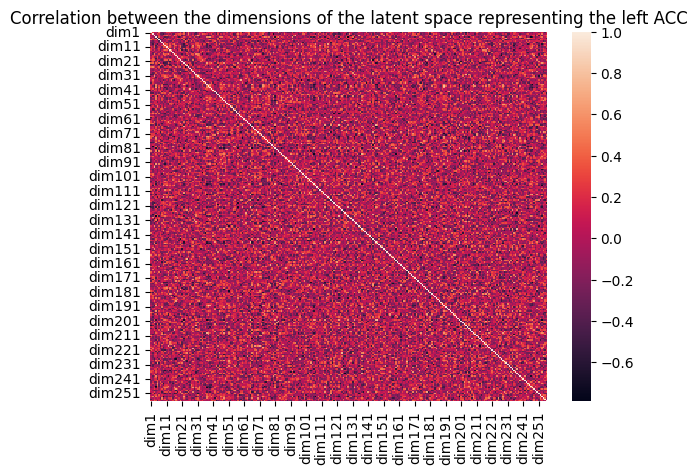

In [20]:
sns.heatmap(left_bdd_UKB.drop('ID', axis=1).corr())
plt.title('Correlation between the dimensions of the latent space representing the left ACC')

In [16]:
right_bdd_UKB = pd.read_csv("/neurospin/dico/adufournet/mycode/Output/CINGULATE_right/14-27-09_138/UKB40_trained_on_WBA_embeddings/full_embeddings.csv")
right_merge = pd.merge(sex_age_df, right_bdd_UKB, left_on='Subject', right_on='ID')
right_merge = right_merge.drop('ID', axis=1)

get_corr_age_sex(right_merge)

Top Age Correlations:
 dim53     0.087972
dim7      0.079955
dim92     0.076089
dim198    0.070985
dim168    0.064238
Name: Correlation_with_Age, dtype: float64
Top Sex Correlations:
 dim9      0.126993
dim64     0.121045
dim124    0.116243
dim54     0.109899
dim71     0.105806
Name: Correlation_with_Sex, dtype: float64


Text(0.5, 1.0, 'Correlation between the dimensions of the latent space representing the right ACC')

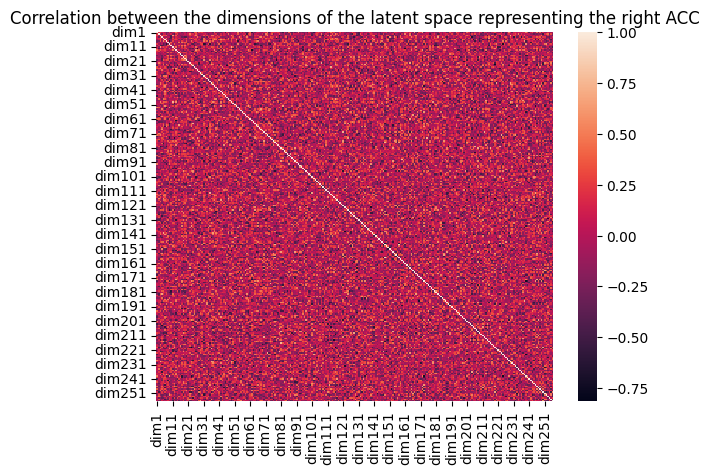

In [21]:
sns.heatmap(right_bdd_UKB.drop('ID', axis=1).corr())
plt.title('Correlation between the dimensions of the latent space representing the right ACC')